SESSION 10 - Classification Algorithms (Part 1: Introduction + Logistic Regression) Topics Covered: What is classification? Binary vs multi-class Logistic Regression Sigmoid function Log-odds interpretation Decision boundary Threshold-based predictions Hands-on: Logistic regression on a binary dataset Plotting sigmoid
Pending
Tasks
1.
Create a Python function sigmoid(x) that takes a numeric input and returns the sigmoid value using the formula 1 / (1 + exp(-x)). Test your function with x = -2, 0, and 3.
2.
Given a dataset of 10 Instagram posts with features 'likes' and 'has_caption' (1 if caption present, 0 if not), and a label 'viral' (1 if post went viral, 0 otherwise), write code to fit a logistic regression model to predict 'viral' using scikit-learn. Print the model coefficients.
3.
Plot the sigmoid function for x values from -10 to 10 using matplotlib, and visually indicate the threshold at 0.5 on the plot.<br><br><em><strong>Hint:</strong> Use plt.axhline() to draw the threshold line.</em>
4.
Given a probability output from your logistic regression model, write a function that classifies the result as 'Viral' or 'Not Viral' based on a threshold value that you can set (default 0.5). Test your function with probabilities 0.2, 0.6, and 0.8 and thresholds 0.5 and 0.7.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# TASK 1: Custom Sigmoid Function

print("--- TASK 1: TESTING CUSTOM SIGMOID FUNCTION ---")
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

test_values = [-2, 0, 3]
for val in test_values:
    print(f"Sigmoid({val:<2}) = {sigmoid(val):.4f}")
print("\n" + "="*50 + "\n")

--- TASK 1: TESTING CUSTOM SIGMOID FUNCTION ---
Sigmoid(-2) = 0.1192
Sigmoid(0 ) = 0.5000
Sigmoid(3 ) = 0.9526




In [3]:
# TASK 2: Logistic Regression on Instagram Dataset
print("--- TASK 2: TRAINING LOGISTIC REGRESSION ---")
# 10 Simulated Instagram posts data
data = {
    'Likes': [1500, 200, 5000, 800, 12000, 300, 4500, 9500, 600, 7000],
    'Has_Caption': [1, 0, 1, 1, 1, 0, 0, 1, 0, 1],
    'Viral': [0, 0, 1, 0, 1, 0, 0, 1, 0, 1]
}
df_insta = pd.DataFrame(data)

# Exporting locally to match your download request
df_insta.to_csv("instagram_viral_data.csv", index=False)

X = df_insta[['Likes', 'Has_Caption']]
y = df_insta['Viral']

# Initializing and fitting Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X, y)

print(f"Intercept (w0): {log_reg.intercept_[0]:.4f}")
print(f"Coefficient for Likes (w1): {log_reg.coef_[0][0]:.6f}")
print(f"Coefficient for Has_Caption (w2): {log_reg.coef_[0][1]:.4f}")
print("\n" + "="*50 + "\n")

--- TASK 2: TRAINING LOGISTIC REGRESSION ---
Intercept (w0): -180.2339
Coefficient for Likes (w1): 0.037944
Coefficient for Has_Caption (w2): 0.0001




<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\disha\AppData\Local\Temp\ipykernel_20912\3447557763.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.plot(x_axis, y_axis, color='blue', linewidth=2.5, label='Sigmoid Curve: $\sigma(x)$')


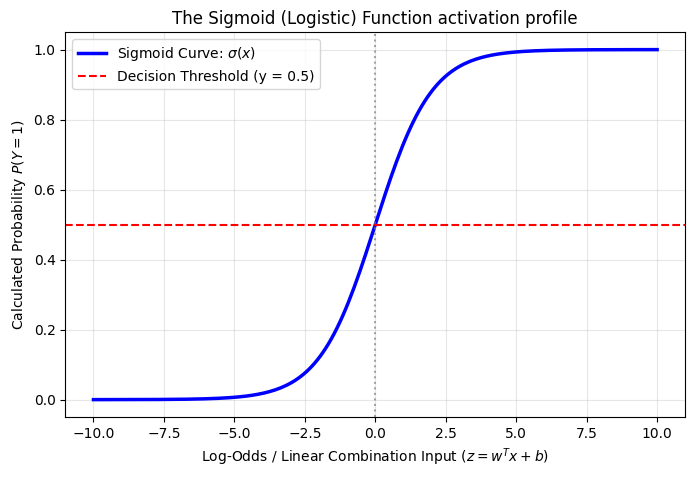

In [4]:
# TASK 3: Plotting the Sigmoid Curve & Classification Boundary
# Generating x values from -10 to 10
x_axis = np.linspace(-10, 10, 200)
y_axis = sigmoid(x_axis)

plt.figure(figsize=(8, 5))
plt.plot(x_axis, y_axis, color='blue', linewidth=2.5, label='Sigmoid Curve: $\sigma(x)$')

# Visual classification threshold line at 0.5
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision Threshold (y = 0.5)')
# Vertical midline marker showing where input equals 0
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.7)

plt.title('The Sigmoid (Logistic) Function activation profile', fontsize=12)
plt.xlabel('Log-Odds / Linear Combination Input ($z = w^Tx + b$)', fontsize=10)
plt.ylabel('Calculated Probability $P(Y=1)$', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# TASK 4: Custom Classification Threshold Testing

print("--- TASK 4: CUSTOM THRESHOLD EVALUATION ---")

def classify_probability(probability, threshold=0.5):
    if probability >= threshold:
        return 'Viral'
    else:
        return 'Not Viral'

# Test scenarios
test_probabilities = [0.2, 0.6, 0.8]
test_thresholds = [0.5, 0.7]

for t in test_thresholds:
    print(f"Evaluating with Decision Threshold = {t}:")
    for p in test_probabilities:
        result = classify_probability(p, threshold=t)
        print(f"  - Predicted Probability: {p:<3} -> Classification: {result}")
    print()

--- TASK 4: CUSTOM THRESHOLD EVALUATION ---
Evaluating with Decision Threshold = 0.5:
  - Predicted Probability: 0.2 -> Classification: Not Viral
  - Predicted Probability: 0.6 -> Classification: Viral
  - Predicted Probability: 0.8 -> Classification: Viral

Evaluating with Decision Threshold = 0.7:
  - Predicted Probability: 0.2 -> Classification: Not Viral
  - Predicted Probability: 0.6 -> Classification: Not Viral
  - Predicted Probability: 0.8 -> Classification: Viral

